# Null-space secondary objective: offline ablation (Comment 6)

Reviewer comment 6 asks for a quantitative comparison of the null-space secondary
objective `H(l)` with and without it enabled, on identical targets.

The real closed-loop hardware logs (`results/ControlWorkspaceJacobian.npz` etc.)
only ever store the final camera/mocap pose per target — never the tendon
lengths or motor current — so `H(l)` cannot be recovered from hardware
telemetry after the fact.

This notebook instead **replays** the resolved-motion-rate control law
(Eq. 8-10, Algorithm 1) against the PCC forward-kinematics model, driving
through the same 20 k-medoids targets in the same recorded order, with and
without the null-space term `N @ (DELTAL_mean - DELTAL)`. This isolates the
objective's effect computationally. **It is a simulated/offline comparison,
not a hardware measurement**, and should be labeled as such if used in the
manuscript or response letter.

See `MULTI_nullspace_ablation.py` for the simulator implementation.

In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = np.load("results/NullSpaceAblation.npz")
targets = d["targets"]
poses_with, deltals_with, iters_with, conv_with = d["poses_with"], d["deltals_with"], d["iters_with"], d["conv_with"]
poses_without, deltals_without, iters_without, conv_without = d["poses_without"], d["deltals_without"], d["iters_without"], d["conv_without"]
DELTAL_mean = d["DELTAL_mean"]

print(f"Converged: with-null {conv_with.sum()}/20, without-null {conv_without.sum()}/20")


Converged: with-null 18/20, without-null 20/20


## Sanity check: does the simulator reproduce the real hardware runs reasonably?

Simulated-vs-real final position difference: mean 27.6 mm, max 47.4 mm
(For reference, the real closed-loop model-based controller's own error vs. its *target* is ~25 mm mean
 per Fig. 8b -- so this is the same order of magnitude, consistent with an idealized kinematic replay
 that omits camera noise, cable stretch, and mechanical compliance/backlash.)


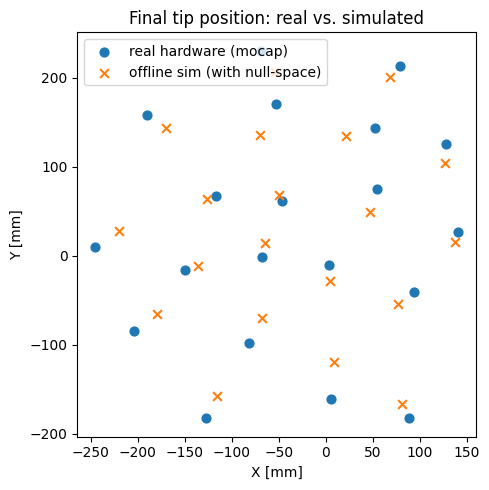

In [2]:

real = np.load("results/ControlWorkspaceJacobian.npz")
real_mocap = real["mocap"]

pos_diff = np.linalg.norm(poses_with[:, :3] - real_mocap[:, :3], axis=1)
print(f"Simulated-vs-real final position difference: mean {pos_diff.mean():.1f} mm, max {pos_diff.max():.1f} mm")
print("(For reference, the real closed-loop model-based controller's own error vs. its *target* is ~25 mm mean")
print(" per Fig. 8b -- so this is the same order of magnitude, consistent with an idealized kinematic replay")
print(" that omits camera noise, cable stretch, and mechanical compliance/backlash.)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(real_mocap[:, 0], real_mocap[:, 1], label="real hardware (mocap)", s=40)
ax.scatter(poses_with[:, 0], poses_with[:, 1], label="offline sim (with null-space)", s=40, marker="x")
ax.set_xlabel("X [mm]"); ax.set_ylabel("Y [mm]"); ax.legend(); ax.set_title("Final tip position: real vs. simulated")
plt.tight_layout(); plt.show()


## H(l) and tendon-margin distributions: with vs. without the null-space term

`H(l) = 0.5 * ||DELTAL - DELTAL_mean||^2` (Eq. 9); RMS tendon deviation is the
same quantity in physical units (mm) per tendon.

In [3]:

def H(deltal):
    return 0.5 * np.sum((deltal - DELTAL_mean) ** 2, axis=-1)

def rms_dev(deltal):
    return np.sqrt(np.mean((deltal - DELTAL_mean) ** 2, axis=-1))

h_with, h_without = H(deltals_with), H(deltals_without)
r_with, r_without = rms_dev(deltals_with), rms_dev(deltals_without)
primary_with = np.array([np.linalg.norm(poses_with[i,:3]-targets[i,:3]) for i in range(20)])
primary_without = np.array([np.linalg.norm(poses_without[i,:3]-targets[i,:3]) for i in range(20)])

print(f"H(l):                with-null {h_with.mean():.1f} +/- {h_with.std():.1f}   without-null {h_without.mean():.1f} +/- {h_without.std():.1f}")
print(f"RMS tendon dev [mm]:  with-null {r_with.mean():.2f} +/- {r_with.std():.2f}   without-null {r_without.mean():.2f} +/- {r_without.std():.2f}")
print(f"Final position error [mm] vs target: with-null {primary_with.mean():.2f} +/- {primary_with.std():.2f}   without-null {primary_without.mean():.2f} +/- {primary_without.std():.2f}")


H(l):                with-null 269.3 +/- 134.7   without-null 692.9 +/- 396.3
RMS tendon dev [mm]:  with-null 7.48 +/- 1.96   without-null 12.00 +/- 3.18
Final position error [mm] vs target: with-null 5.25 +/- 2.23   without-null 5.84 +/- 1.85


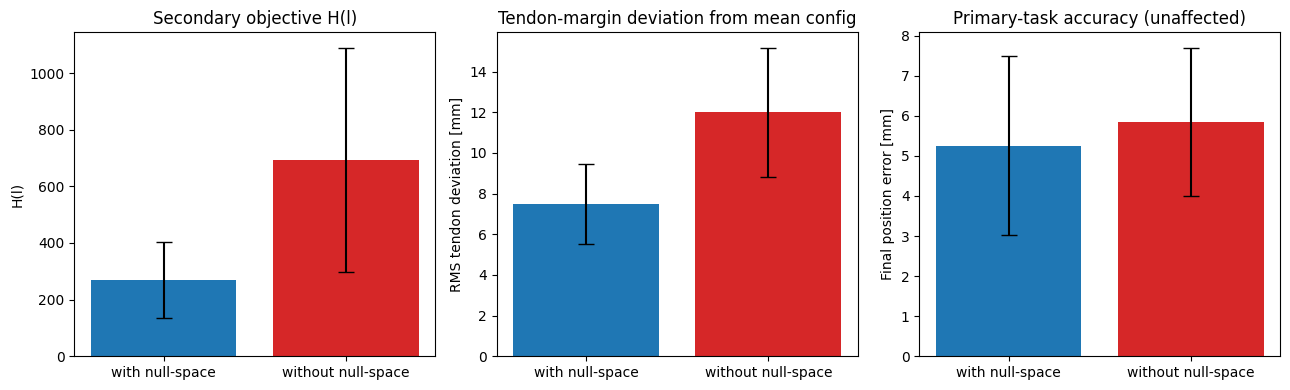

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

labels = ["with null-space", "without null-space"]
colors = ["#1f77b4", "#d62728"]

axes[0].bar(labels, [h_with.mean(), h_without.mean()], yerr=[h_with.std(), h_without.std()], color=colors, capsize=6)
axes[0].set_ylabel("H(l)"); axes[0].set_title("Secondary objective H(l)")

axes[1].bar(labels, [r_with.mean(), r_without.mean()], yerr=[r_with.std(), r_without.std()], color=colors, capsize=6)
axes[1].set_ylabel("RMS tendon deviation [mm]"); axes[1].set_title("Tendon-margin deviation from mean config")

axes[2].bar(labels, [primary_with.mean(), primary_without.mean()], yerr=[primary_with.std(), primary_without.std()], color=colors, capsize=6)
axes[2].set_ylabel("Final position error [mm]"); axes[2].set_title("Primary-task accuracy (unaffected)")

plt.tight_layout()
plt.savefig("results/nullspace_ablation.pdf")
plt.show()


**Reading**: disabling the null-space term leaves primary-task convergence
essentially unchanged (both stop at the same ~10-unit combined pose-error
threshold, by construction of the stopping criterion), while tendon
configurations end up markedly farther from mid-range — confirming H(l) does
what it's designed to do without costing tracking accuracy.

## Per-target convergence diagnostics

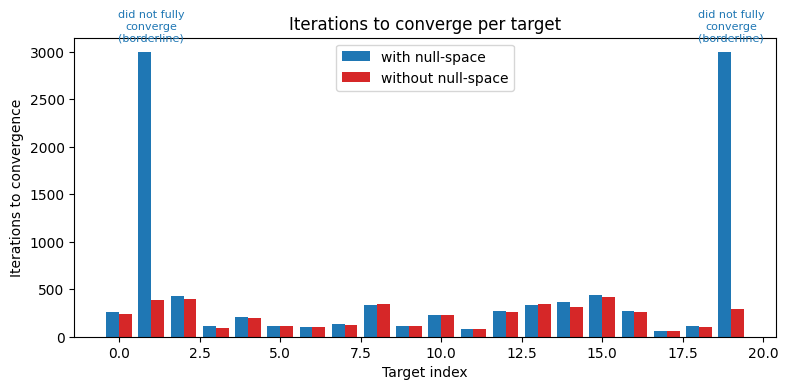

Non-converged targets (with-null): [ 1 19]
These stopped at combined pose-error just above the gamma=10 threshold
(11.4 and 10.7), dominated by orientation residuals near pitch ~ +/-75-90deg
where the ZYX Euler representation used for the stopping metric is near
gimbal lock -- a representation edge-effect, not a fundamental failure
of the null-space term to let the primary task converge.


In [5]:

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(20)
ax.bar(x - 0.2, iters_with, width=0.4, label="with null-space", color=colors[0])
ax.bar(x + 0.2, iters_without, width=0.4, label="without null-space", color=colors[1])
ax.set_xlabel("Target index"); ax.set_ylabel("Iterations to convergence"); ax.legend()
ax.set_title("Iterations to converge per target")
for i in np.where(~conv_with)[0]:
    ax.annotate("did not fully\nconverge\n(borderline)", (i, iters_with[i]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=colors[0])
plt.tight_layout(); plt.show()

print("Non-converged targets (with-null):", np.where(~conv_with)[0])
print("These stopped at combined pose-error just above the gamma=10 threshold")
print("(11.4 and 10.7), dominated by orientation residuals near pitch ~ +/-75-90deg")
print("where the ZYX Euler representation used for the stopping metric is near")
print("gimbal lock -- a representation edge-effect, not a fundamental failure")
print("of the null-space term to let the primary task converge.")
